In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from uravu import plotting
from uravu.relationship import Relationship
import _fig_params

# Multi-modal data

Let's use nest sampling to investigate a multi-modal parameter space.
Using PXRD as a modal system.

In [18]:
angle = np.linspace(20, 50, 60)
intensity = (0.7 * norm.pdf(angle, loc=25, scale=0.75)) + (
             0.3 * norm.pdf(angle, loc=38, scale=1.5)) + np.random.randn(60) * 0.005
uncertainty = np.ones(angle.size) * 0.015

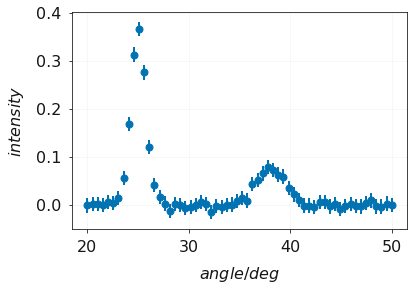

In [3]:
plt.errorbar(angle, intensity, uncertainty, marker='o', ls='')
plt.xlabel('$angle/deg$')
plt.ylabel('$intensity$')
plt.show()

We will model the diffraction data as a pair of Gaussians.

In [4]:
def diff(angle, a, b, c, d, e, f):
    return a * norm.pdf(angle, loc=b, scale=c) + d * norm.pdf(angle, loc=e, scale=f)

These bounds define *uniform priors*.

In [5]:
bounds = ((0, 1), (20, 50), (0.1, 2), 
          (0, 1), (20, 50), (0.1, 2))

The `uravu` package makes using nested sampling and MCMC as easy as `scipy.optimize.curve_fit`

In [6]:
r = Relationship(diff, angle, intensity, ordinate_error=uncertainty, bounds=bounds)

We can maximise the likelihood.

In [7]:
r.max_likelihood('diff_evo')

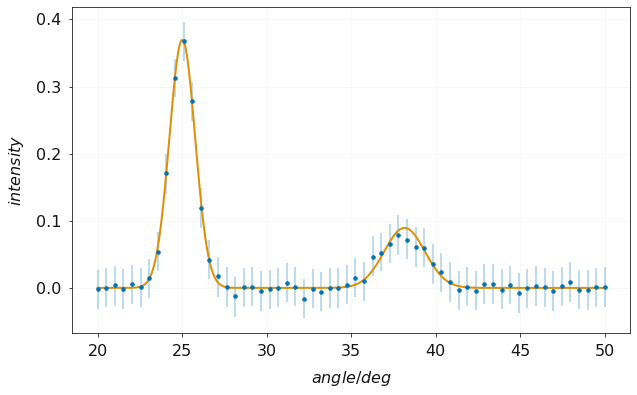

In [8]:
plotting.plot_relationship(r)
plt.xlabel('$angle/deg$')
plt.ylabel('$intensity$')
plt.show()

Nested sampling is capable of sampling multi-modal parameter spaces, better than MCMC.

In [9]:
r.nested_sampling()

10430it [10:22, 16.76it/s, +500 | bound: 51 | nc: 1 | ncall: 57047 | eff(%): 19.160 | loglstar:   -inf < 178.828 <    inf | logz: 158.578 +/-  0.287 | dlogz:  0.001 >  0.509]


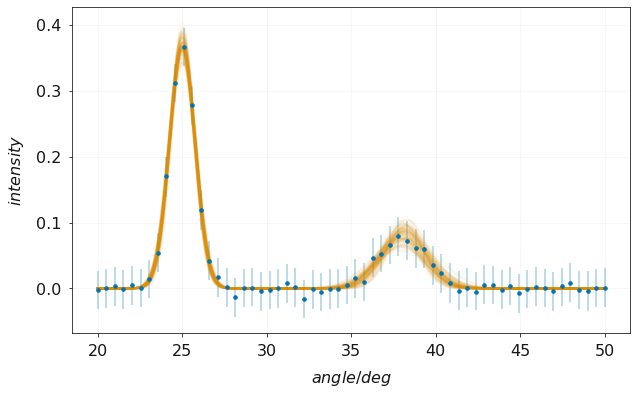

In [10]:
plotting.plot_relationship(r)
plt.xlabel('$angle/deg$')
plt.ylabel('$intensity$')
plt.show()

We can also plot the parameter space (this time it is 6 dimensional).

In [14]:
flatchain = np.array([r.variables[i].samples for i in range(6)]).T

In [15]:
import corner

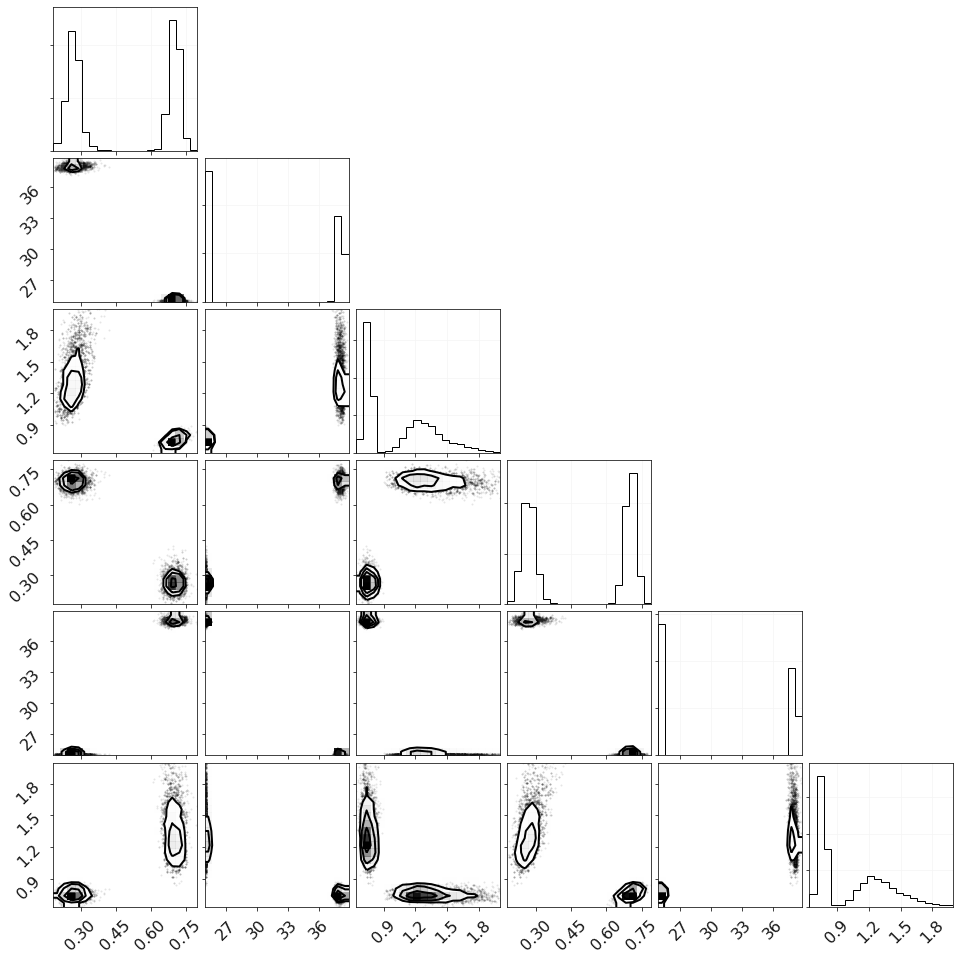

In [19]:
corner.corner(flatchain);